# Imports


In [ ]:
import pandas as pd
import re
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels import robust


warnings.filterwarnings("ignore")


PATH = "../data/raw/untouched_raw_original.csv"
REPORTS = "../reports/"
OUTPUT = "../data/raw/listings_cleaned.csv"

df = pd.read_csv(PATH)
len(df)

14185

In [ ]:
%matplotlib inline
mpl.rcParams["figure.dpi"] = 150
mpl.rcParams["figure.edgecolor"] = "black"
mpl.rcParams["axes.linewidth"] = 0.5

sns.set()
rc = {
    "font.family": ["serif"],
    "font.serif": "Times New Roman",
    "grid.color": "gainsboro",
    "grid.linestyle": "-",
}
sns.set_style(rc=rc)
sns.set_context("notebook", font_scale=0.8)


# Cleaning


## Property Condition


In [ ]:
# df = df[df['bedrooms']<=4]
# df

In [ ]:
fc = [r"\$", "dollars", "dollar", "usd"]
fc_pattern = "|".join(fc)
has_fc = df["description"].str.contains(fc_pattern, case=False, na=False)
df.loc[has_fc, "price_tag"] = "foreign"

In [ ]:
x = np.log1p(df["price"])

q1, q3 = np.percentile(x, [25, 75])
iqr = q3 - q1

l1 = q1 - 1.5 * iqr
l2 = q3 + 1.5 * iqr

print(f"l1: {l1} l2: {l2}")

l1: 5.120675930167277 l2: 12.108471023148848


In [ ]:
def plot_price(df, cutoff=5000, l1=12, l2=17):
    plt.figure(num=1, figsize=(20, 10), linewidth=1)
    plt.subplot2grid((2, 3), (0, 0))
    sns.distplot(df["price"])
    plt.subplot2grid((2, 3), (0, 1))
    sns.distplot(np.log1p(df["price"]))
    plt.axvline(x=l1, color="b", linestyle=":")
    plt.axvline(x=l2, color="b", linestyle=":")
    plt.xlabel("log(1+price)")
    ax = plt.subplot2grid((2, 3), (0, 2))
    sm.qqplot(np.log1p(df["price"]), stats.norm, fit=True, line="45", ax=ax)
    plt.subplot2grid((2, 3), (1, 0), colspan=3)
    red = dict(markerfacecolor="r", markeredgecolor="r", marker=".")
    df.price.plot(kind="box", xlim=(0, cutoff), vert=False, flierprops=red)

    plt.tight_layout()


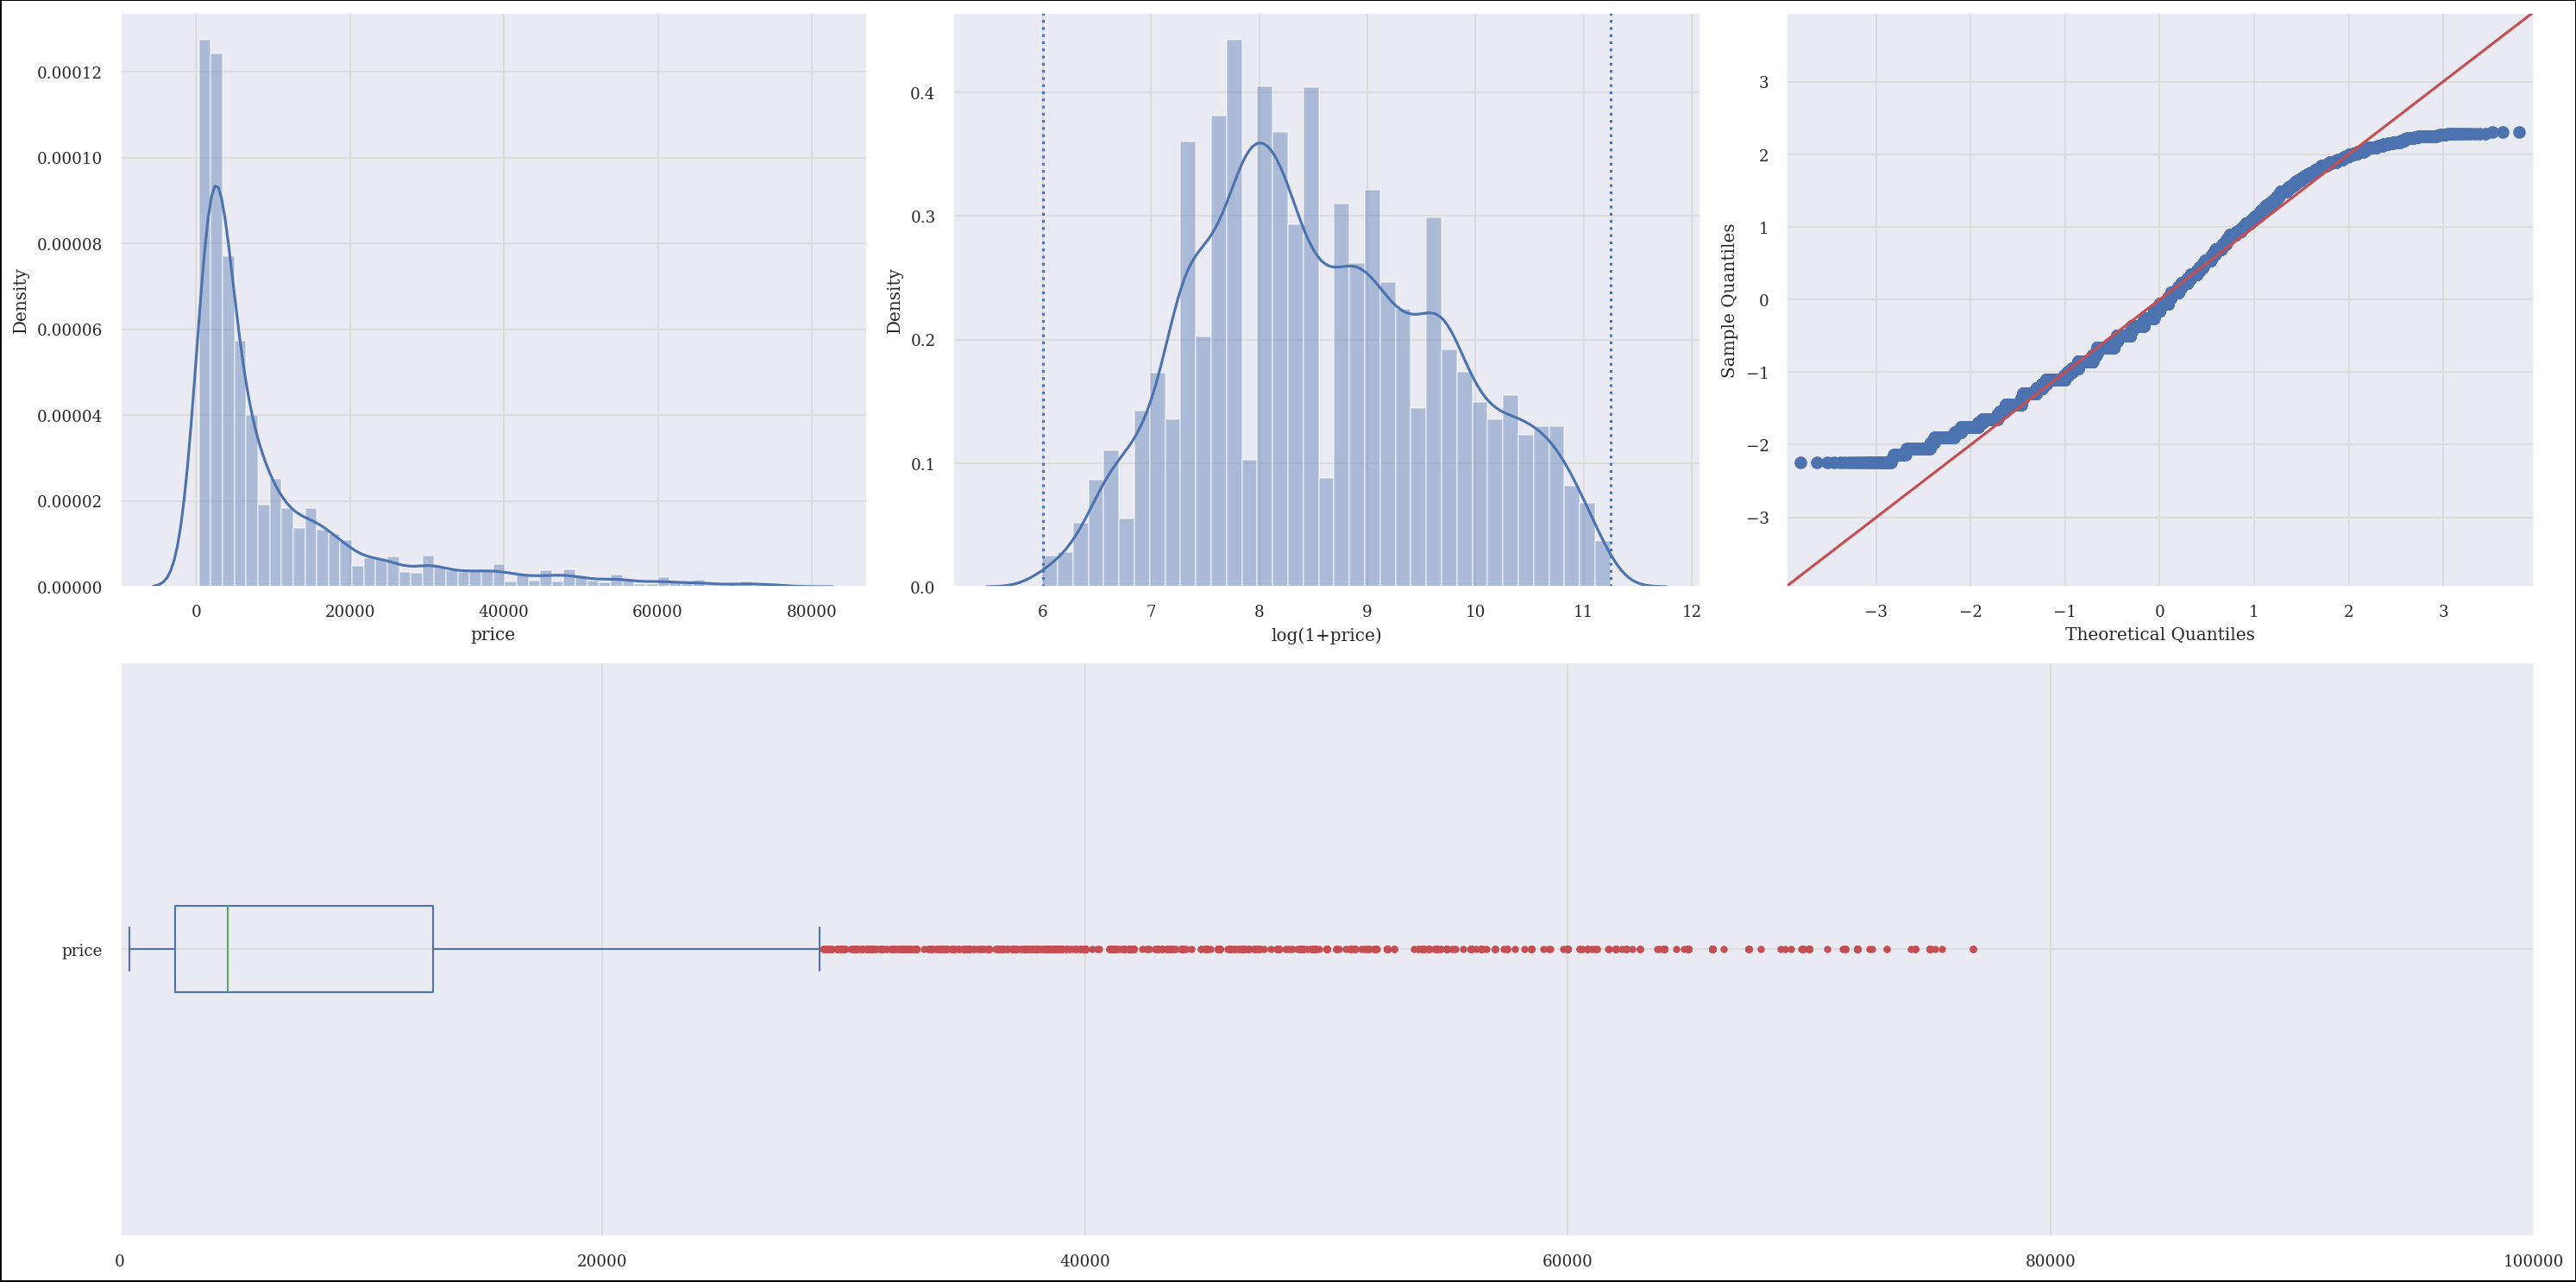

In [ ]:
l1 = 6
l2 = 11.25
plot_price(rental_df, cutoff=100_000, l1=l1, l2=l2)


In [ ]:
outliers = df[(np.log1p(df["price"]) < l1) | (np.log1p(df["price"]) > l2)]
print(f"Number of listings which are found to outliers: {len(outliers)}\n")
print(f"Outlier range: prices below {np.exp(l1) - 1} and above {np.exp(l2) - 1}")


Number of listings which are found to outliers: 226

Outlier range: prices below 364.0374678653289 and above 76878.91976467776


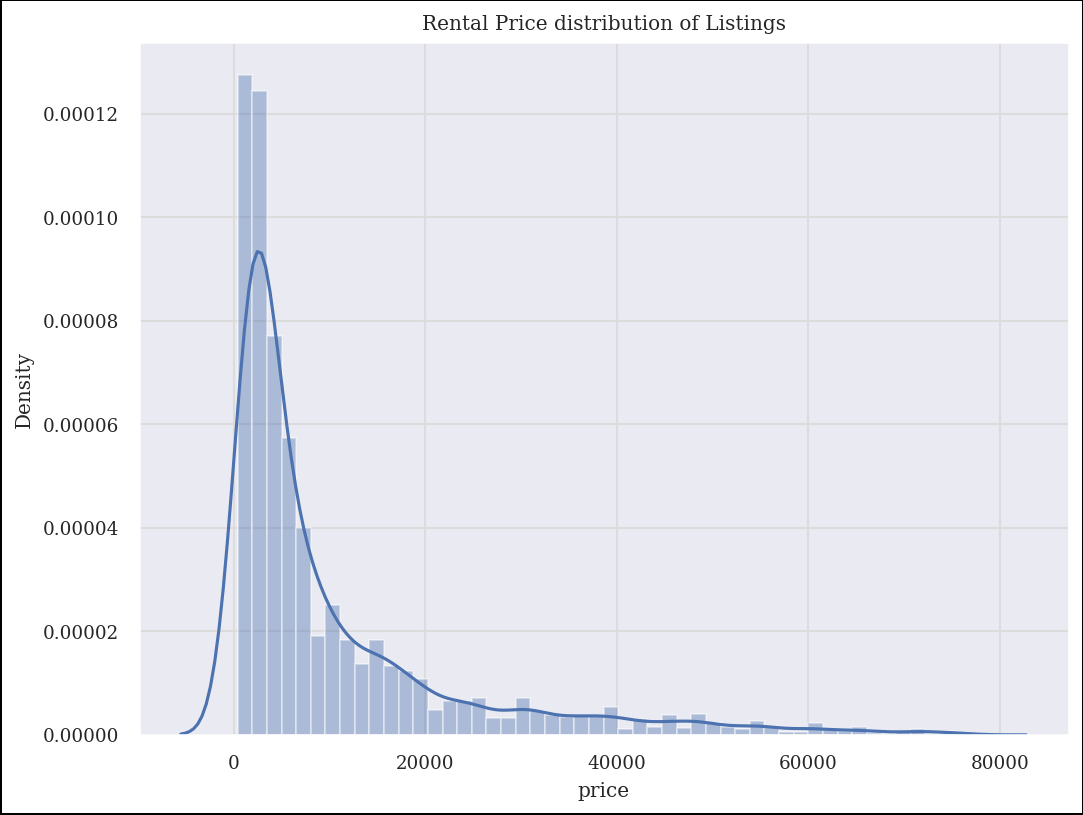

In [ ]:
plt.figure(num=1, figsize=(8, 6), linewidth=1)
rental_df = df.drop(index=outliers.index)
sns.distplot(rental_df.price)

_ = plt.title("Rental Price distribution of Listings")


In [ ]:
rental_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13959 entries, 0 to 14184
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   url                  13959 non-null  object 
 1   title                13959 non-null  object 
 2   description          13959 non-null  object 
 3   fetch_date           13805 non-null  object 
 4   house_type           13959 non-null  object 
 5   bathrooms            13959 non-null  int64  
 6   bedrooms             13959 non-null  int64  
 7   price                13959 non-null  float64
 8   locality             13959 non-null  object 
 9   Condition            13959 non-null  object 
 10  Furnishing           13959 non-null  object 
 11  property_size        13959 non-null  float64
 12  24-hour Electricity  13959 non-null  int64  
 13  Air Conditioning     13959 non-null  int64  
 14  Apartment            13959 non-null  int64  
 15  Balcony              13959 non-null  int6

In [ ]:
len(rental_df)

13959

In [ ]:
len(rental_df[rental_df["price"] > 50000])

370